In [6]:
import os
import pickle
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

# Percorso della cartella contenente i dati

# Funzione per caricare i batch
def carica_file_batch(batch_path):
    with open(batch_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
        data = batch[b'data']
        labels = batch[b'labels']
        return data, labels

# Carica i dati di addestramento (5 batch)
X_train_list, y_train_list = [], []
for i in range(1, 6):
    X_file_batch, y_file_batch = carica_file_batch(f"/kaggle/input/cifar10/cifar-10-batches-py/data_batch_{i}")#percorso del i-esimo file da caricare
    X_train_list.append(X_file_batch)
    y_train_list.extend(y_file_batch)

# Unisco i dati di addestramento (sia osservazioni che target)
X_train_pieno = np.concatenate(X_train_list, axis=0)
y_train_pieno = np.array(y_train_list)#trasformo in array

# Carica i dati di test
X_test, y_test =  carica_file_batch(f"/kaggle/input/cifar10/cifar-10-batches-py/test_batch")#carico il file per il test e metto osservazioni e target in X_test e y_test
X_test = np.array(X_test)#lo trasformo in array
y_test = np.array(y_test)

# Normalizza i dati (così ho solo valori tra 0 e 1)
X_train_pieno = X_train_pieno / 255.0
X_test = X_test / 255.0

# Codifica le etichette
#le = LabelEncoder()
#y_train_full_encoded = le.fit_transform(y_train_pieno)
#y_test_encoded = le.transform(y_test)



# Unione di train e test
X_completo = np.concatenate([X_train_pieno, X_test], axis=0)
y_completo = np.concatenate([y_train_pieno, y_test], axis=0)

partizione=10000
# Sottocampiona a 10.000 osservazioni totali
X_sottoinsieme, _, y_sottoinsieme, _ = train_test_split(
    X_completo, y_completo, train_size=partizione, stratify=y_completo, random_state=42
)

# Suddivide in 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sottoinsieme, y_sottoinsieme, test_size=0.2, stratify=y_sottoinsieme, random_state=42
)
X_val, X_test_finale, y_val, y_test_finale = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)





In [7]:
# Definizione modelli e griglie parametri
param_grid = {

    "Regressione Logistica": {
        "modello": LogisticRegression(max_iter=2000),
        "parametri": {
            "C": [0.1, 1, 10],
            "solver": ['lbfgs', 'liblinear']
        }
    },
   "SVM": {
        "modello": SVC(),
        "parametri": {
            "C": [0.1,1,10], 
            "kernel": ['linear', 'rbf','poly']
        }
    },
  
    "k-NN": {
        "modello": KNeighborsClassifier(),
        "parametri": {
            "n_neighbors": [3, 5, 7],
            "weights": ['uniform', 'distance'],
            "metric": ['euclidean', 'manhattan', 'minkowski']
        }
    },
    "Albero Decisionale": {
        "modello": DecisionTreeClassifier(),
        "parametri": {
            "max_depth": [10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            "criterion": ['gini', 'entropy']
        }
    }
}

# Ricerca dei migliori iperparametri
mod_migliore = None
acc_migliore = 0
nome_mod_migliore = ""

print("\nRicerca iperparametri per i vari modelli\n")
for nome in param_grid:
    print(f"{nome}:\n")
    grid = GridSearchCV(param_grid[nome]["modello"], param_grid[nome]["parametri"], cv=3, scoring='accuracy', n_jobs=-1)#n_jobs = -1, indica di usare tutti i core della cpu
    grid.fit(X_train, y_train)
    pred_val = grid.predict(X_val)
    acc_val = accuracy_score(y_val, pred_val)
    print(f"{nome} Accuratezza: {acc_val:.4f}, Parametri migliori: {grid.best_params_}\n")
    if acc_val > acc_migliore:
        acc_migliore = acc_val
        mod_migliore = grid.best_estimator_
        nome_mod_migliore = nome

print(f"\nIl modello migliore è: {nome_mod_migliore}, con una accuratezza di: {acc_migliore:.4f}\n")


Ricerca iperparametri per i vari modelli

Regressione Logistica:



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Regressione Logistica Accuratezza: 0.3670, Parametri migliori: {'C': 0.1, 'solver': 'liblinear'}

SVM:

SVM Accuratezza: 0.4690, Parametri migliori: {'C': 10, 'kernel': 'rbf'}

k-NN:

k-NN Accuratezza: 0.3160, Parametri migliori: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}

Albero Decisionale:

Albero Decisionale Accuratezza: 0.2630, Parametri migliori: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


Il modello migliore è: SVM, con una accuratezza di: 0.4690



In [8]:

#Unisco il training e il validation set
X_train_val = np.concatenate([X_train, X_val], axis=0)
y_train_val = np.concatenate([y_train, y_val], axis=0)
#Rialleno il modello sul training completo
mod_migliore.fit(X_train_val, y_train_val)
# Test finale sul modello migliore
pred_test = mod_migliore.predict(X_test_finale)
acc_test = accuracy_score(y_test_finale, pred_test)
print(f"\nAccuratezza calcolata sul test set: {acc_test:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test_finale, pred_test))



Accuratezza calcolata sul test set: 0.4780

Classification Report:

              precision    recall  f1-score   support

           0       0.57      0.56      0.57       100
           1       0.56      0.59      0.57       100
           2       0.41      0.43      0.42       100
           3       0.22      0.25      0.23       100
           4       0.47      0.38      0.42       100
           5       0.31      0.34      0.32       100
           6       0.52      0.49      0.51       100
           7       0.56      0.50      0.53       100
           8       0.61      0.65      0.63       100
           9       0.63      0.59      0.61       100

    accuracy                           0.48      1000
   macro avg       0.49      0.48      0.48      1000
weighted avg       0.49      0.48      0.48      1000




Ecco la matrice di confusione del modello migliore



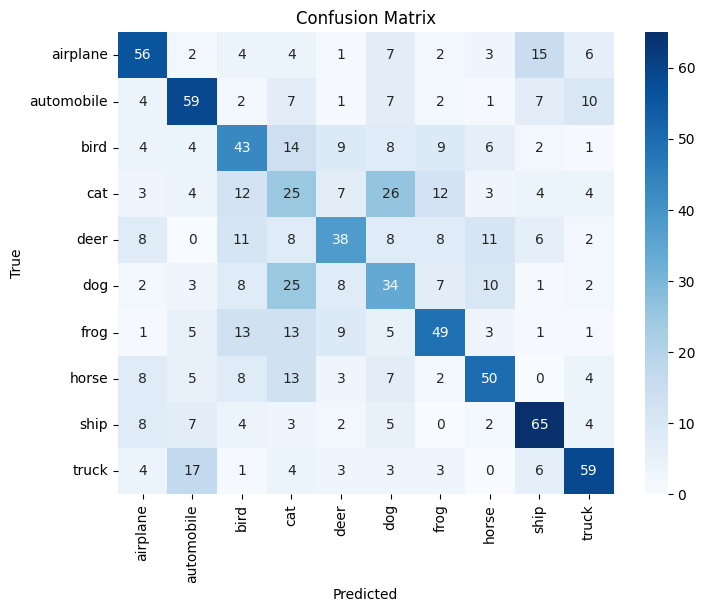

In [9]:

import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix_multiclass(cm,class_labels):
    """
    Visualizza una matrice di confusione come heatmap.

    Parameters:
    -----------
    cm : numpy.ndarray
        La matrice di confusione da visualizzare

    class_labels: lista contentente le label/etichette delle classi: associa alla classe 0=primo elemento nella lista e così via

    """
    # Calcola dinamicamente le etichette delle classi
    #class_labels = [f"Class {i}" for i in range(cm.shape[0])]
    
    # Visualizza la heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']#associo ai valori 0,1,2,... i nomi degli elementi da classificare
print("\nEcco la matrice di confusione del modello migliore\n")
cm=confusion_matrix(y_test_finale, pred_test)

plot_confusion_matrix_multiclass(cm,class_names)